In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score,mean_squared_error

In [ ]:
day_data=pd.read_csv("/content/drive/MyDrive/data set/day.csv")
hour_data=pd.read_csv("/content/drive/MyDrive/data set/hour.csv")

In [ ]:
day_data.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [ ]:
hour_data.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [ ]:
day_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [ ]:
hour_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [ ]:
day_data.shape

(731, 16)

In [ ]:
hour_data.shape

(17379, 17)

In [ ]:
day_data['dteday'] = pd.to_datetime(day_data['dteday'])

In [ ]:
day_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

In [ ]:
hour_data['dteday'] = pd.to_datetime(hour_data['dteday'])

In [ ]:
hour_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

In [ ]:
day_data.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
726,False
727,False
728,False
729,False


In [ ]:
day_data.duplicated().sum()

np.int64(0)

In [ ]:
hour_data.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
17374,False
17375,False
17376,False
17377,False


In [ ]:
hour_data.duplicated().sum()

np.int64(0)

In [ ]:
day_data.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [ ]:
hour_data.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [ ]:
day_data.describe()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452


In [ ]:
hour_data.describe()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2012-01-02 04:08:34.552045568,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,5017.0295,NaN,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599


In [ ]:
day_data.shape

(731, 16)

In [ ]:
day_data.drop(['instant', 'dteday', 'yr', 'casual', 'registered'], axis=1, inplace=True)

In [ ]:
day_data.describe()

,season,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,2.496580,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,4504.348837
std,1.110807,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,1937.211452
min,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,22.000000
25%,2.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,3152.000000
50%,3.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,4548.000000
75%,3.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,5956.000000
max,4.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,8714.000000


In [ ]:
day_data.shape

(731, 11)

In [ ]:
hour_data.shape

(17379, 17)

In [ ]:
hour_data.drop(['instant', 'dteday', 'yr', 'casual', 'registered'], axis=1, inplace=True)

In [ ]:
hour_data.describe()

,season,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
count,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,2.501640,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,189.463088
std,1.106918,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,181.387599
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,40.000000
50%,3.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,142.000000
75%,3.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,281.000000
max,4.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,977.000000


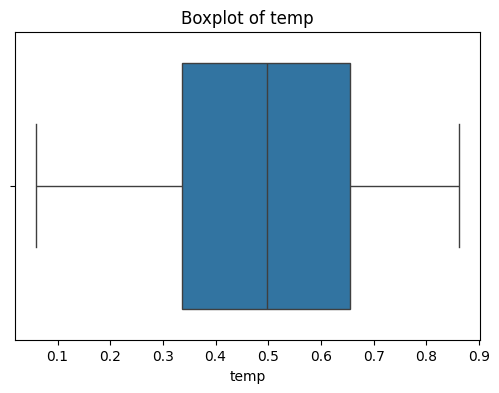

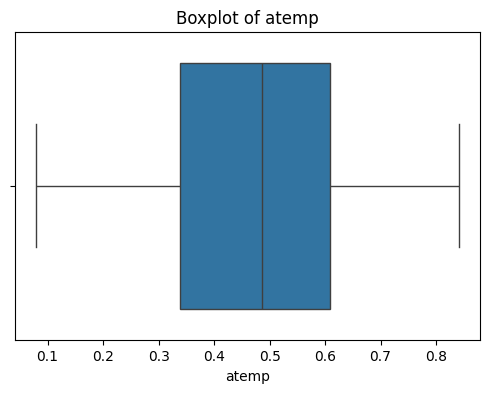

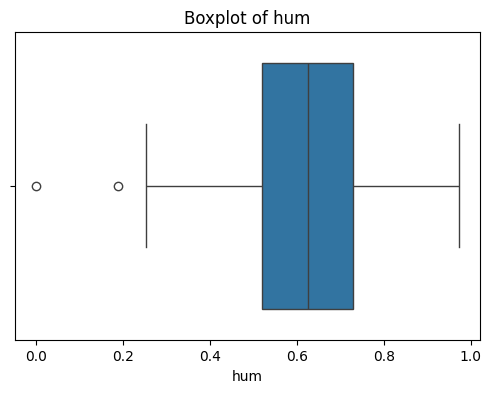

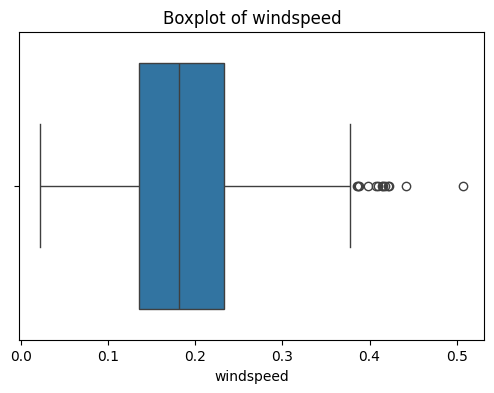

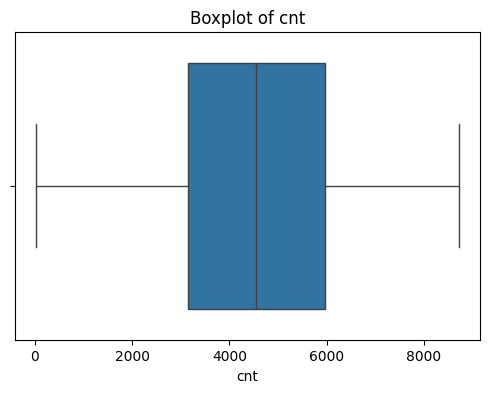

(731, 11)

In [ ]:
column_name =["temp", "atemp", "hum", "windspeed", "cnt"]

for col in column_name:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=day_data[col])
    plt.title(f'Boxplot of {col}')
    plt.show()
day_data.shape

In [ ]:
num_cols = day_data.select_dtypes(include=['float64','int64']).columns

for col in num_cols:
    Q1 = day_data[col].quantile(0.25)
    Q3 = day_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    day_data = day_data[(day_data[col] >= lower) & (day_data[col] <= upper)]

print("After outlier removal:", day_data.shape)


After outlier removal: (696, 11)


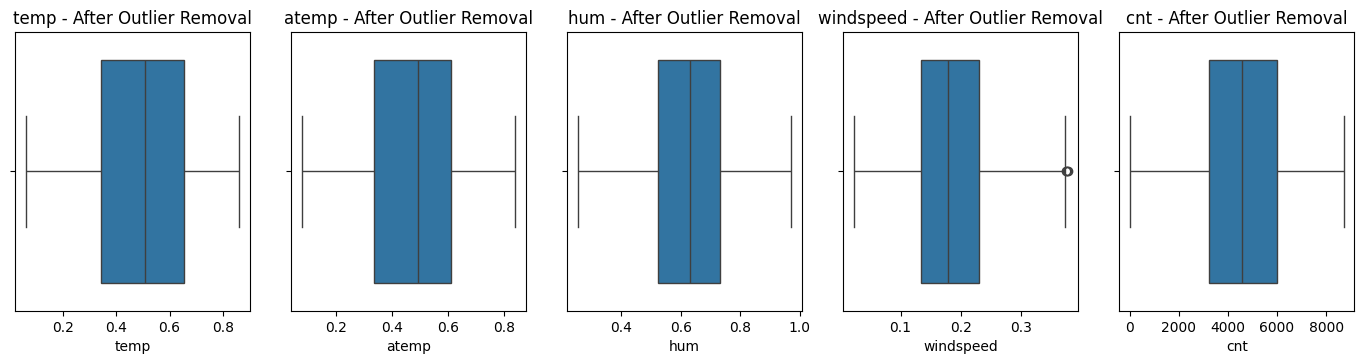

In [ ]:
plt.figure(figsize=(14, 4))
cols= ["temp", "atemp", "hum", "windspeed", "cnt"]
for i, col in enumerate(cols):
    plt.subplot(1,len(cols),i+1)
    sns.boxplot(x=day_data[col])
    plt.title(f"{col} - After Outlier Removal")
    plt.tight_layout(pad=2)

In [ ]:
day_data.isnull().sum()

,0
season,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0
atemp,0
hum,0
windspeed,0


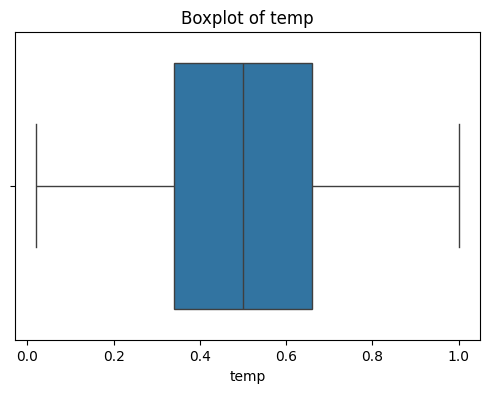

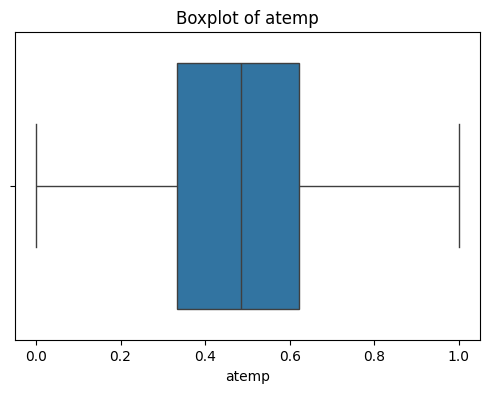

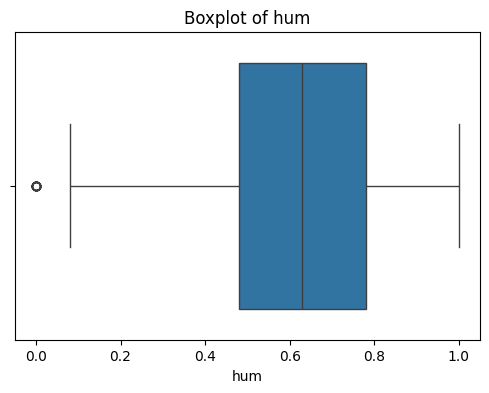

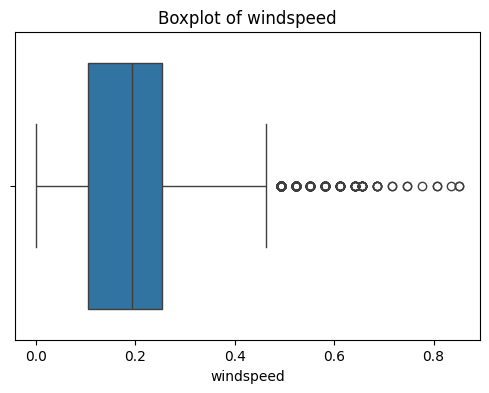

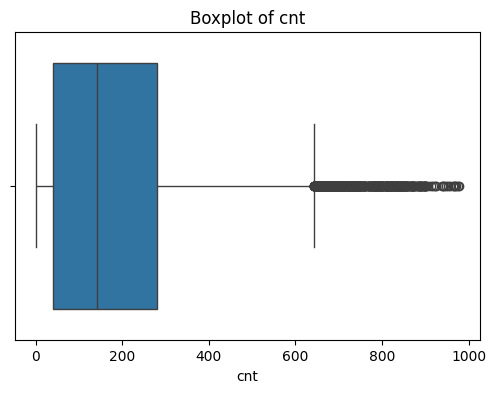

(17379, 12)

In [ ]:
column_name =["temp", "atemp", "hum", "windspeed", "cnt"]

for col in column_name:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=hour_data[col])
    plt.title(f'Boxplot of {col}')
    plt.show()
hour_data.shape

In [ ]:
num_cols = hour_data.select_dtypes(include=['float64','int64']).columns

for col in num_cols:
    Q1 = hour_data[col].quantile(0.25)
    Q3 = hour_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    hour_data = hour_data[(hour_data[col] >= lower) & (hour_data[col] <= upper)]

print("After outlier removal:", hour_data.shape)

After outlier removal: (16042, 12)


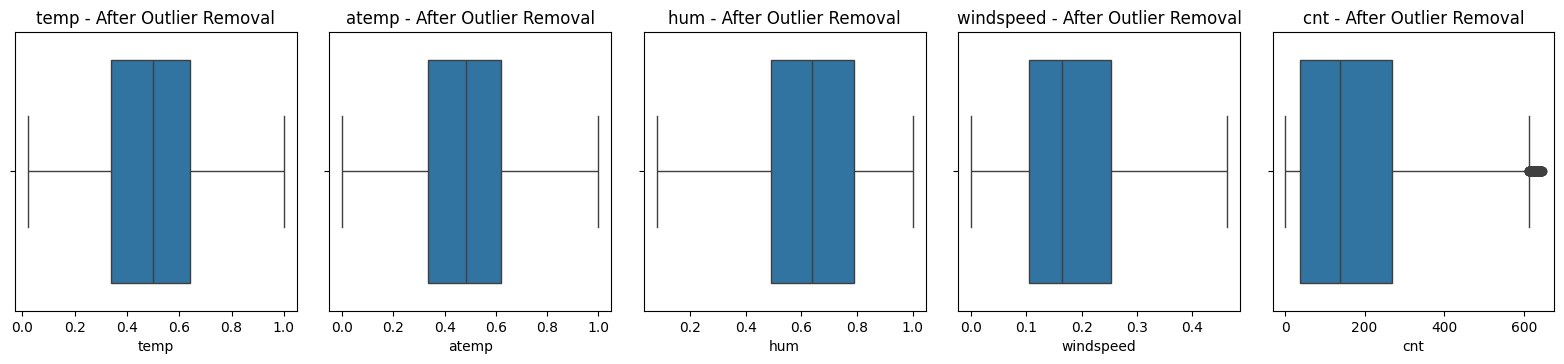

In [ ]:
plt.figure(figsize=(16, 4))
cols= ["temp", "atemp", "hum", "windspeed", "cnt"]
for i, col in enumerate(cols):
    plt.subplot(1,len(cols),i+1)
    sns.boxplot(x=hour_data[col])
    plt.title(f"{col} - After Outlier Removal")
    plt.tight_layout(pad=2)

In [ ]:
hour_data.isnull().sum()

,0
season,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0
atemp,0
hum,0


DAY DATA

In [ ]:
X = day_data.drop(columns=['cnt'])
y = day_data['cnt']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
lr_r2 = r2_score(y_test, y_pred_lr)
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print("Linear Regression Results")
print("R2 Score:", lr_r2)
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)


Linear Regression Results
R2 Score: 0.46515272306696354
MAE: 1039.040260019337
RMSE: 1302.5521216630882


In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(
    n_estimators=200,

    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_r2 = r2_score(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("\nRandom Forest Results")
print("R2 Score:", rf_r2)
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)



Random Forest Results
R2 Score: 0.8642022761611281
MAE: 38.36755749454659
RMSE: 57.680811407342325


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

gb_r2 = r2_score(y_test, y_pred_gb)
gb_mae = mean_absolute_error(y_test, y_pred_gb)
gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))

print("\nGradient Boosting Results")
print("R2 Score:", gb_r2)
print("MAE:", gb_mae)
print("RMSE:", gb_rmse)



Gradient Boosting Results
R2 Score: 0.7695173219637268
MAE: 53.23190446624353
RMSE: 75.14572199709418


In [ ]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'R2 Score': [lr_r2, rf_r2, gb_r2],
    'MAE': [lr_mae, rf_mae, gb_mae],
    'RMSE': [lr_rmse, rf_rmse, gb_rmse]
})

print(results)


               Model  R2 Score        MAE        RMSE
0  Linear Regression  0.355123  95.384800  125.696585
1      Random Forest  0.864202  38.367557   57.680811
2  Gradient Boosting  0.769517  53.231904   75.145722


In [ ]:

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions
y_train_pred_lr = lr_model.predict(X_train)
y_test_pred_lr = lr_model.predict(X_test)

# R2 scores
train_r2_lr = r2_score(y_train, y_train_pred_lr)
test_r2_lr = r2_score(y_test, y_test_pred_lr)

print("Linear Regression (Day Data)")
print("Train Accuracy (R2):", train_r2_lr)
print("Test Accuracy (R2):", test_r2_lr)

Linear Regression (Day Data)
Train Accuracy (R2): 0.36307620454289824
Test Accuracy (R2): 0.3551232365788698


In [ ]:


rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predictions
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

# R2 scores
train_r2_rf = r2_score(y_train, y_train_pred_rf)
test_r2_rf = r2_score(y_test, y_test_pred_rf)

print("\nRandom Forest (Day Data)")
print("Train Accuracy (R2):", train_r2_rf)
print("Test Accuracy (R2):", test_r2_rf)


Random Forest (Day Data)
Train Accuracy (R2): 0.9812510439306903
Test Accuracy (R2): 0.8642022761611281


In [ ]:
gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

# Predictions
y_train_pred_gb = gb_model.predict(X_train)
y_test_pred_gb = gb_model.predict(X_test)

# R2 scores
train_r2_gb = r2_score(y_train, y_train_pred_gb)
test_r2_gb = r2_score(y_test, y_test_pred_gb)

print("\nGradient Boosting (Day Data)")
print("Train Accuracy (R2):", train_r2_gb)
print("Test Accuracy (R2):", test_r2_gb)


Gradient Boosting (Day Data)
Train Accuracy (R2): 0.8109533956352082
Test Accuracy (R2): 0.8027622338100919


In [ ]:
accuracy_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'Train R2': [train_r2_lr, train_r2_rf, train_r2_gb],
    'Test R2': [test_r2_lr, test_r2_rf, test_r2_gb]
})

print(accuracy_comparison)


               Model  Train R2   Test R2
0  Linear Regression  0.363076  0.355123
1      Random Forest  0.981251  0.864202
2  Gradient Boosting  0.810953  0.802762


HYPERPARAMETER TUNING FOR DAY DATA

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import randint

In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_rf_grid = grid_search.best_estimator_
y_pred_grid = best_rf_grid.predict(X_test)

print("Grid Search Best Params:", grid_search.best_params_)
print("Grid Search R2:", r2_score(y_test, y_pred_grid))


Grid Search Best Params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Grid Search R2: 0.8442103465680336


In [ ]:
param_dist = {
    'n_estimators': randint(100, 400),
    'max_depth': [5, 10, 15],
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5)
}

random_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_dist,
    n_iter=15,
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_rf_random = random_search.best_estimator_
y_pred_random = best_rf_random.predict(X_test)

print("\nRandom Search Best Params:", random_search.best_params_)
print("Random Search R2:", r2_score(y_test, y_pred_random))



Random Search Best Params: {'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 4, 'n_estimators': 314}
Random Search R2: 0.8622610973464684


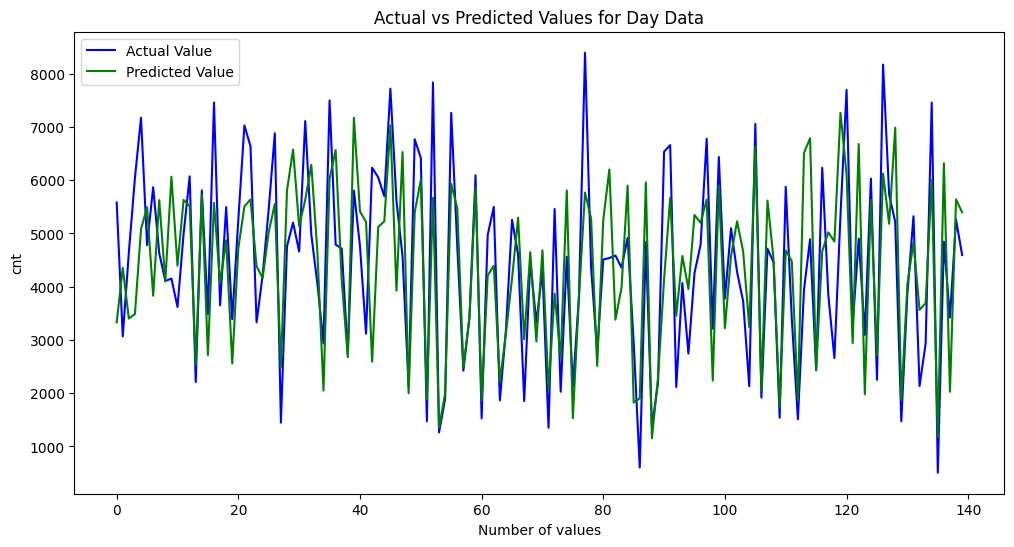

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Re-run RandomizedSearchCV for day data to ensure the model is trained on day_data features
param_dist_day = {
    'n_estimators': randint(100, 400),
    'max_depth': [5, 10, 15],
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5)
}

random_search_day = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_dist_day,
    n_iter=15,
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

random_search_day.fit(X_train_day, y_train_day) # Use the correctly separated day_data train set

best_rf_random_day_model = random_search_day.best_estimator_
y_pred_random_day = best_rf_random_day_model.predict(X_test_day) # Use the correctly separated day_data test set

plt.figure(figsize=(12, 6))
plt.plot(y_test_day.tolist(), color='blue', label = 'Actual Value')
plt.plot(y_pred_random_day, color='green', label='Predicted Value')
plt.title('Actual vs Predicted Values for Day Data')
plt.xlabel('Number of values')
plt.ylabel('cnt')
plt.legend()
plt.show()

In [ ]:
X = hour_data.drop(columns=['cnt'])
y = hour_data['cnt']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
lr_r2 = r2_score(y_test, y_pred_lr)
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression (Hour Data)")
print("R2 Score:", lr_r2)
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)

Linear Regression (Hour Data)
R2 Score: 0.3551232365788698
MAE: 95.38480009368142
RMSE: 125.69658537909247


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_r2 = r2_score(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("\nRandom Forest (Hour Data)")
print("R2 Score:", rf_r2)
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)


Random Forest (Hour Data)
R2 Score: 0.864141359779376
MAE: 38.342108139557894
RMSE: 57.69374723671543


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

gb_r2 = r2_score(y_test, y_pred_gb)
gb_mae = mean_absolute_error(y_test, y_pred_gb)
gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))

print("\nGradient Boosting (Hour Data)")
print("R2 Score:", gb_r2)
print("MAE:", gb_mae)
print("RMSE:", gb_rmse)


Gradient Boosting (Hour Data)
R2 Score: 0.8027622338100919
MAE: 49.37207780082715
RMSE: 69.51526031322284


In [ ]:
import pandas as pd

results_hour = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'R2 Score': [lr_r2, rf_r2, gb_r2],
    'MAE': [lr_mae, rf_mae, gb_mae],
    'RMSE': [lr_rmse, rf_rmse, gb_rmse]
})

print(results_hour)

               Model  R2 Score        MAE        RMSE
0  Linear Regression  0.355123  95.384800  125.696585
1      Random Forest  0.864141  38.342108   57.693747
2  Gradient Boosting  0.802762  49.372078   69.515260


In [ ]:


lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_train_pred_lr = lr_model.predict(X_train)
y_test_pred_lr = lr_model.predict(X_test)
train_r2_lr = r2_score(y_train, y_train_pred_lr)
test_r2_lr = r2_score(y_test, y_test_pred_lr)
print("Linear Regression (Hour Data)")
print("Train Accuracy (R2):", train_r2_lr)
print("Test Accuracy (R2):", test_r2_lr)

Linear Regression (Hour Data)
Train Accuracy (R2): 0.36307620454289824
Test Accuracy (R2): 0.3551232365788698


In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)
train_r2_rf = r2_score(y_train, y_train_pred_rf)
test_r2_rf = r2_score(y_test, y_test_pred_rf)

print("\nRandom Forest (Hour Data)")
print("Train Accuracy (R2):", train_r2_rf)
print("Test Accuracy (R2):", test_r2_rf)


Random Forest (Hour Data)
Train Accuracy (R2): 0.9813352139378063
Test Accuracy (R2): 0.864141359779376


In [ ]:
gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)
y_train_pred_gb = gb_model.predict(X_train)
y_test_pred_gb = gb_model.predict(X_test)
train_r2_gb = r2_score(y_train, y_train_pred_gb)
test_r2_gb = r2_score(y_test, y_test_pred_gb)
print("\nGradient Boosting (Hour Data)")
print("Train Accuracy (R2):", train_r2_gb)
print("Test Accuracy (R2):", test_r2_gb)


Gradient Boosting (Hour Data)
Train Accuracy (R2): 0.8109533956352082
Test Accuracy (R2): 0.8027622338100919


In [ ]:
accuracy_hour = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'Train R2': [train_r2_lr, train_r2_rf, train_r2_gb],
    'Test R2': [test_r2_lr, test_r2_rf, test_r2_gb]
})

print(accuracy_hour)

               Model  Train R2   Test R2
0  Linear Regression  0.363076  0.355123
1      Random Forest  0.981335  0.864141
2  Gradient Boosting  0.810953  0.802762


HYPERPARAMETER TUNING

In [ ]:
from sklearn.model_selection import train_test_split

X = hour_data.drop(columns=['cnt'])
y = hour_data['cnt']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=42)
params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20]
}
search = GridSearchCV(rf, params, cv=3)
search.fit(X_train, y_train)
print("Best Params:", search.best_params_)
print("Best Score:", search.best_score_)
best_model = search.best_estimator_

Best Params: {'max_depth': 20, 'n_estimators': 200}
Best Score: 0.853166480552653


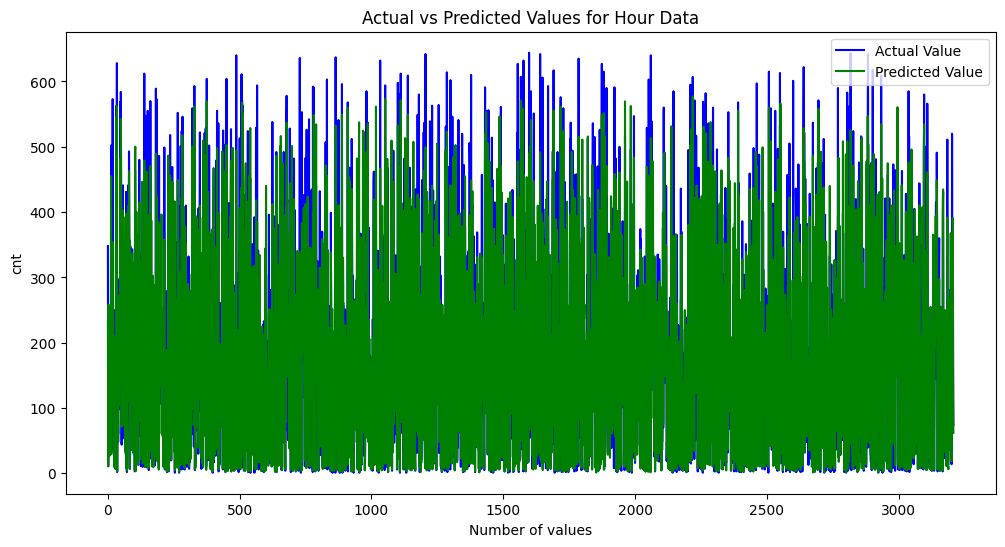

In [ ]:
y_test_list = list(y_test)

plt.figure(figsize=(12, 6))
plt.plot(y_test_list, color='blue', label = 'Actual Value')
plt.plot(y_pred_rf, color='green', label='Predicted Value')
plt.title('Actual vs Predicted Values for Hour Data')
plt.xlabel('Number of values')
plt.ylabel('cnt')
plt.legend()
plt.show()